# Neural Network Power Prediction
## Data Cleaning, Preprocessing & NN with Hyperparameter Optimization

**Goal:** Predict Power [kW] using Date features + POA Irradiance [W/m²]  
**Approach:**
1. Load & combine all monthly sheets
2. Add sunlight availability feature (zero power = no sun)
3. Full data cleaning & preprocessing
4. Train/Validation/Test split
5. Neural Network with hyperparameter optimization (Optuna + PyTorch)

In [1]:
# Install & verify dependencies
import subprocess, sys
for pkg in ['torch', 'optuna', 'pandas', 'openpyxl', 'scikit-learn', 'matplotlib', 'seaborn']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import torch
import optuna
print(f'PyTorch version: {torch.__version__}')
print(f'Optuna version:  {optuna.__version__}')
print(f'CUDA available:  {torch.cuda.is_available()}')
print('All packages installed successfully!')

PyTorch version: 2.10.0+cpu
Optuna version:  4.7.0
CUDA available:  False
All packages installed successfully!


c:\Users\AbdulSaleem.Shaik\Desktop\harmonic-data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Step 1: Load Data from All Sheets

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load ALL sheets
xlsx = pd.ExcelFile('hourly data set 8 12 2025.xlsx')
print(f'Found {len(xlsx.sheet_names)} sheets:')

all_dfs = []
for sheet in xlsx.sheet_names:
    tmp = pd.read_excel(xlsx, sheet_name=sheet)
    all_dfs.append(tmp)
    print(f'  {sheet}: {tmp.shape[0]} rows x {tmp.shape[1]} cols')

# Common columns
common_cols = set(all_dfs[0].columns)
for d in all_dfs[1:]:
    common_cols = common_cols & set(d.columns)
common_cols = sorted(common_cols)

df_raw = pd.concat([d[common_cols] for d in all_dfs], ignore_index=True)
print(f'\nCombined: {df_raw.shape[0]} rows x {df_raw.shape[1]} cols')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head()

Found 13 sheets:
  sept hourly 2024: 720 rows x 16 cols
  oct hourly 2024: 744 rows x 16 cols
  nov hourly 2024: 720 rows x 16 cols
  dec hourly 2024: 744 rows x 16 cols
  jan hourly 2025 : 744 rows x 16 cols
  feb hourly 2025: 672 rows x 16 cols
  march hourly 2025: 744 rows x 16 cols
  april hourly 2025: 720 rows x 16 cols
  may hourly 2025: 744 rows x 16 cols
  june hourly 2025: 720 rows x 12 cols
  july hourly 2025: 744 rows x 16 cols
  august hourly 2025: 744 rows x 16 cols
  sept hourly 2025: 720 rows x 16 cols

Combined: 9480 rows x 11 cols
Columns: ['Current AC (INV-1 Huawei SUN2000-60KTL-M0) [A]', 'Current AC (INV2 Huawei SUN2000-60KTL-M0) [A]', 'Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A]', 'Date', 'Normalized Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A / Impp]', 'Normalized Current DC (INV2 Huawei SUN2000-60KTL-M0) [A / Impp]', 'Normalized Voltage DC (INV-1 Huawei SUN2000-60KTL-M0) [V / Umpp]', 'POA irradiance (sensor) [W/m²]', 'Power [kW]', 'Voltage AC (INV2 Huawei SUN

,Current AC (INV-1 Huawei SUN2000-60KTL-M0) [A],Current AC (INV2 Huawei SUN2000-60KTL-M0) [A],Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A],Date,Normalized Current DC (INV-1 Huawei SUN2000-60KTL-M0) [A / Impp],Normalized Current DC (INV2 Huawei SUN2000-60KTL-M0) [A / Impp],Normalized Voltage DC (INV-1 Huawei SUN2000-60KTL-M0) [V / Umpp],POA irradiance (sensor) [W/m²],Power [kW],Voltage AC (INV2 Huawei SUN2000-60KTL-M0) [V],Voltage DC (INV2 Huawei SUN2000-60KTL-M0) [V]
0,0.0,0.0,0.0,2024-09-01 00:00:00,0.0,0.0,0.0,0.01,0,0.0,0.0
1,0.0,0.0,0.0,2025-09-01 01:00:00,0.0,0.0,0.0,0.01,0,0.0,0.0
2,0.0,0.0,0.0,2025-09-01 02:00:00,0.0,0.0,0.0,0.01,0,0.0,0.0
3,0.0,0.0,0.0,2025-09-01 03:00:00,0.0,0.0,0.0,0.01,0,0.0,0.0
4,0.0,0.0,0.0,2025-09-01 04:00:00,0.0,0.0,0.0,0.01,0,0.0,0.0


---
## Step 2: Data Cleaning & Sunlight Feature Engineering

**Key insight:** Zero power means no sunlight → we add a binary feature `Sunlight` (1 = sun available, 0 = no sun).  
We keep ALL data (including nighttime zeros) so the model learns when the sun is NOT available.

In [3]:
# Identify columns
date_col = 'Date'
power_col = 'Power [kW]'
poa_col = 'POA irradiance (sensor) [W/m²]'

# Build working dataset
df = df_raw[[date_col, power_col, poa_col]].copy()
df[date_col] = pd.to_datetime(df[date_col])
df[power_col] = pd.to_numeric(df[power_col], errors='coerce')
df[poa_col] = pd.to_numeric(df[poa_col], errors='coerce')

print(f'Before cleaning: {len(df)} rows')
print(f'Missing values:\n{df.isnull().sum()}')
print(f'\nDuplicates: {df.duplicated().sum()}')

# Drop missing values and duplicates
df = df.dropna().drop_duplicates().reset_index(drop=True)
print(f'\nAfter cleaning: {len(df)} rows')

Before cleaning: 9480 rows
Missing values:
Date                                0
Power [kW]                        549
POA irradiance (sensor) [W/m²]    599
dtype: int64

Duplicates: 260

After cleaning: 8621 rows


In [4]:
# === FEATURE ENGINEERING ===

# 1. Sunlight availability (POA > 0 means sun is shining)
df['Sunlight'] = (df[poa_col] > 0).astype(int)

# 2. Date-derived features
df['Hour'] = df[date_col].dt.hour
df['Month'] = df[date_col].dt.month
df['DayOfYear'] = df[date_col].dt.dayofyear
df['DayOfWeek'] = df[date_col].dt.dayofweek
df['WeekOfYear'] = df[date_col].dt.isocalendar().week.astype(int)

# 3. Cyclical encoding of Hour and Month (captures circular nature)
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['DayOfYear_sin'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
df['DayOfYear_cos'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)

# 4. Timestamp as numeric (hours from start)
df['Timestamp_h'] = (df[date_col] - df[date_col].min()).dt.total_seconds() / 3600

print(f'Total features created: {len(df.columns) - 3}')  # minus Date, Power, POA
print(f'\nSunlight distribution:')
print(df['Sunlight'].value_counts().rename({0: 'No Sun (night)', 1: 'Sun (day)'}))
print(f'\nDataset shape: {df.shape}')
df.head()

Total features created: 13

Sunlight distribution:
Sunlight
Sun (day)         8388
No Sun (night)     233
Name: count, dtype: int64

Dataset shape: (8621, 16)


,Date,Power [kW],POA irradiance (sensor) [W/m²],Sunlight,Hour,Month,DayOfYear,DayOfWeek,WeekOfYear,Hour_sin,Hour_cos,Month_sin,Month_cos,DayOfYear_sin,DayOfYear_cos,Timestamp_h
0,2024-09-01 00:00:00,0.0,0.01,1,0,9,245,6,35,0.000000,1.000000,-1.0,-1.836970e-16,-0.880012,-0.474951,0.0
1,2025-09-01 01:00:00,0.0,0.01,1,1,9,244,0,36,0.258819,0.965926,-1.0,-1.836970e-16,-0.871706,-0.490029,8761.0
2,2025-09-01 02:00:00,0.0,0.01,1,2,9,244,0,36,0.500000,0.866025,-1.0,-1.836970e-16,-0.871706,-0.490029,8762.0
3,2025-09-01 03:00:00,0.0,0.01,1,3,9,244,0,36,0.707107,0.707107,-1.0,-1.836970e-16,-0.871706,-0.490029,8763.0
4,2025-09-01 04:00:00,0.0,0.01,1,4,9,244,0,36,0.866025,0.500000,-1.0,-1.836970e-16,-0.871706,-0.490029,8764.0


CLEANED DATA SUMMARY

Total samples: 8621
Date range: 2024-09-01 00:00:00 → 2025-12-31 23:00:00

Power [kW]:
  Mean:   18.78
  Std:    25.02
  Min:    0.00
  Max:    90.54
  Zeros:  3793 (44.0%)

POA Irradiance [W/m²]:
  Mean:   176.82
  Max:    1002.42
  Zeros:  233 (2.7%)


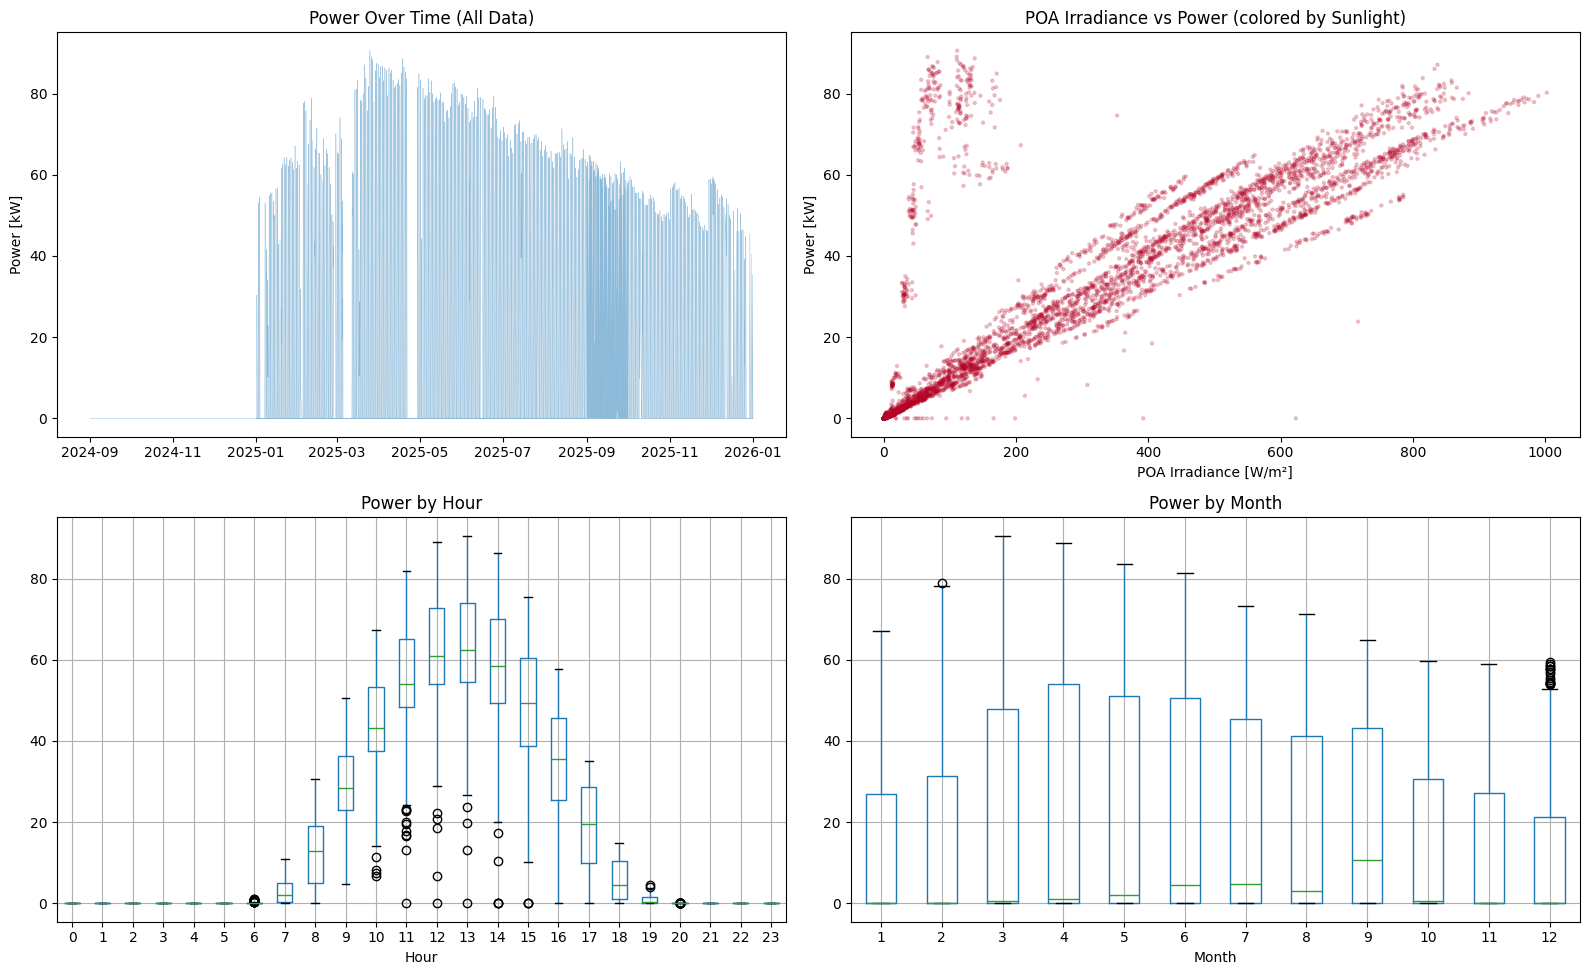

In [5]:
# === DATA OVERVIEW AFTER CLEANING ===
print('='*60)
print('CLEANED DATA SUMMARY')
print('='*60)
print(f'\nTotal samples: {len(df)}')
print(f'Date range: {df[date_col].min()} → {df[date_col].max()}')
print(f'\nPower [kW]:')
print(f'  Mean:   {df[power_col].mean():.2f}')
print(f'  Std:    {df[power_col].std():.2f}')
print(f'  Min:    {df[power_col].min():.2f}')
print(f'  Max:    {df[power_col].max():.2f}')
print(f'  Zeros:  {(df[power_col] == 0).sum()} ({(df[power_col] == 0).mean()*100:.1f}%)')
print(f'\nPOA Irradiance [W/m²]:')
print(f'  Mean:   {df[poa_col].mean():.2f}')
print(f'  Max:    {df[poa_col].max():.2f}')
print(f'  Zeros:  {(df[poa_col] == 0).sum()} ({(df[poa_col] == 0).mean()*100:.1f}%)')

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(df[date_col], df[power_col], alpha=0.5, linewidth=0.3)
axes[0,0].set_title('Power Over Time (All Data)')
axes[0,0].set_ylabel('Power [kW]')

axes[0,1].scatter(df[poa_col], df[power_col], alpha=0.2, s=5, c=df['Sunlight'], cmap='coolwarm')
axes[0,1].set_title('POA Irradiance vs Power (colored by Sunlight)')
axes[0,1].set_xlabel('POA Irradiance [W/m²]')
axes[0,1].set_ylabel('Power [kW]')

df.boxplot(column=power_col, by='Hour', ax=axes[1,0])
axes[1,0].set_title('Power by Hour')
axes[1,0].set_xlabel('Hour')

df.boxplot(column=power_col, by='Month', ax=axes[1,1])
axes[1,1].set_title('Power by Month')
axes[1,1].set_xlabel('Month')

plt.suptitle('')
plt.tight_layout()
plt.show()

---
## Step 3: Data Preprocessing & Train/Validation/Test Split

Split: **70% Training / 15% Validation / 15% Testing** (time-ordered to avoid data leakage)

In [6]:
from sklearn.preprocessing import StandardScaler

# Define features and target
feature_cols = [
    poa_col, 'Sunlight',
    'Hour', 'Month', 'DayOfYear', 'DayOfWeek', 'WeekOfYear',
    'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos',
    'DayOfYear_sin', 'DayOfYear_cos', 'Timestamp_h'
]

X = df[feature_cols].values
y = df[power_col].values

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# Time-ordered split (no shuffling — respects temporal order)
n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f'\nSplit sizes:')
print(f'  Training:   {len(X_train)} samples ({len(X_train)/n*100:.1f}%)')
print(f'  Validation: {len(X_val)} samples ({len(X_val)/n*100:.1f}%)')
print(f'  Testing:    {len(X_test)} samples ({len(X_test)/n*100:.1f}%)')

# Standardize features (fit on training data only)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Also scale target for better NN training
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f'\nScaled X_train: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}')
print(f'Scaled y_train: mean={y_train_scaled.mean():.4f}, std={y_train_scaled.std():.4f}')
print('\nPreprocessing complete!')

Features (14): ['POA irradiance (sensor) [W/m²]', 'Sunlight', 'Hour', 'Month', 'DayOfYear', 'DayOfWeek', 'WeekOfYear', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DayOfYear_sin', 'DayOfYear_cos', 'Timestamp_h']
X shape: (8621, 14)
y shape: (8621,)

Split sizes:
  Training:   6034 samples (70.0%)
  Validation: 1293 samples (15.0%)
  Testing:    1294 samples (15.0%)

Scaled X_train: mean=-0.0000, std=1.0000
Scaled y_train: mean=0.0000, std=1.0000

Preprocessing complete!


---
## Step 4: Neural Network with Hyperparameter Optimization

Using **PyTorch** for the Neural Network and **Optuna** for hyperparameter tuning.  
Optuna will search for the best:
- Number of hidden layers (1–4)
- Neurons per layer (32–256)
- Learning rate
- Dropout rate
- Batch size

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Convert to tensors
X_train_t = torch.FloatTensor(X_train_scaled).to(device)
y_train_t = torch.FloatTensor(y_train_scaled).to(device)
X_val_t = torch.FloatTensor(X_val_scaled).to(device)
y_val_t = torch.FloatTensor(y_val_scaled).to(device)
X_test_t = torch.FloatTensor(X_test_scaled).to(device)
y_test_t = torch.FloatTensor(y_test_scaled).to(device)

print(f'Tensors created on {device}')
print(f'  X_train: {X_train_t.shape}')
print(f'  X_val:   {X_val_t.shape}')
print(f'  X_test:  {X_test_t.shape}')

Using device: cpu
Tensors created on cpu
  X_train: torch.Size([6034, 14])
  X_val:   torch.Size([1293, 14])
  X_test:  torch.Size([1294, 14])


In [8]:
# === NEURAL NETWORK MODEL DEFINITION ===
class PowerNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, hidden_units, dropout_rate):
        super(PowerNet, self).__init__()
        layers = []
        in_features = input_dim
        for i in range(hidden_layers):
            layers.append(nn.Linear(in_features, hidden_units))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_units))
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_features = hidden_units
        layers.append(nn.Linear(in_features, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze()

# === OPTUNA OBJECTIVE FUNCTION ===
def objective(trial):
    # Hyperparameters to optimize
    n_layers = trial.suggest_int('n_layers', 1, 4)
    n_units = trial.suggest_categorical('n_units', [32, 64, 128, 256])
    dropout = trial.suggest_float('dropout', 0.0, 0.5, step=0.1)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    
    # Create model
    model = PowerNet(
        input_dim=X_train_t.shape[1],
        hidden_layers=n_layers,
        hidden_units=n_units,
        dropout_rate=dropout
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # DataLoader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Training loop (30 epochs for tuning — fast)
    model.train()
    for epoch in range(30):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_X)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
    
    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()
    
    return val_loss

print('Model and objective function defined.')
print('Ready for hyperparameter optimization!')

Model and objective function defined.
Ready for hyperparameter optimization!


In [9]:
# === HYPERPARAMETER OPTIMIZATION WITH OPTUNA ===
print('='*60)
print('STARTING HYPERPARAMETER OPTIMIZATION')
print('='*60)
print('Running 50 trials to find the best architecture...\n')

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=False)

print(f'\nOptimization complete!')
print(f'Best trial:')
print(f'  Validation MSE: {study.best_value:.6f}')
print(f'\nBest Hyperparameters:')
for key, value in study.best_params.items():
    print(f'  {key}: {value}')

STARTING HYPERPARAMETER OPTIMIZATION
Running 50 trials to find the best architecture...


Optimization complete!
Best trial:
  Validation MSE: 0.012860

Best Hyperparameters:
  n_layers: 2
  n_units: 128
  dropout: 0.30000000000000004
  lr: 0.0015304852121831463
  batch_size: 64


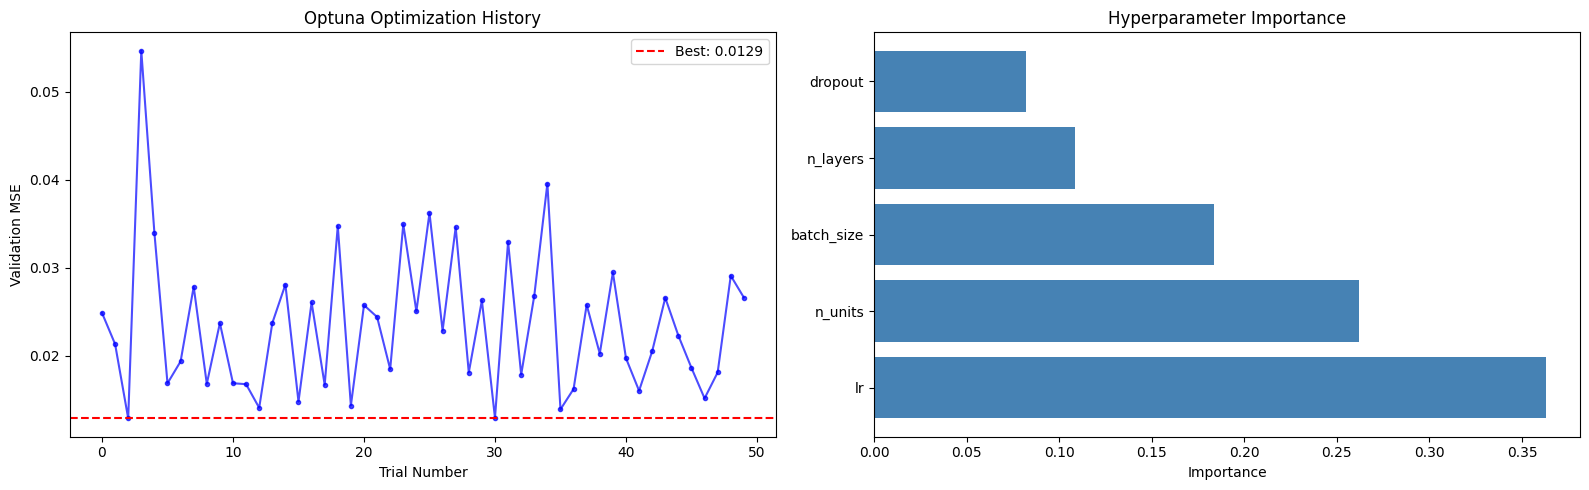

In [10]:
# === VISUALIZATION: Optimization History ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Optimization history
trials = study.trials
values = [t.value for t in trials if t.value is not None]
axes[0].plot(range(len(values)), values, 'b-o', markersize=3, alpha=0.7)
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Validation MSE')
axes[0].set_title('Optuna Optimization History')
axes[0].axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].legend()

# Parameter importance
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()), color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Hyperparameter Importance')

plt.tight_layout()
plt.show()

---
## Step 5: Train Best Model on Full Training Data

In [12]:

# ── 6. Train Best Model ──────────────────────────────────────────────────────
best = study.best_params
print("Training best model with hyperparameters:")
for k, v in best.items():
    print(f"  {k}: {v}")

best_model = PowerNet(
    input_dim=X_train_t.shape[1],
    hidden_layers=best['n_layers'],
    hidden_units=best['n_units'],
    dropout_rate=best['dropout']
).to(device)

optimizer = torch.optim.Adam(best_model.parameters(), lr=best['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=best['batch_size'], shuffle=True)

# Training with early stopping
n_epochs = 200
patience = 20
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []

print(f"\nTraining for up to {n_epochs} epochs (early stopping patience={patience})...")

for epoch in range(n_epochs):
    # Training
    best_model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = best_model(X_batch).squeeze()
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    train_loss = epoch_loss / len(train_dataset)
    train_losses.append(train_loss)
    
    # Validation
    best_model.eval()
    with torch.no_grad():
        val_pred = best_model(X_val_t).squeeze()
        val_loss = criterion(val_pred, y_val_t).item()
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = best_model.state_dict().copy()
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    if patience_counter >= patience:
        print(f"\n  Early stopping at epoch {epoch+1}")
        break

# Load best weights
best_model.load_state_dict(best_state)
print(f"\nTraining complete! Best validation loss: {best_val_loss:.6f}")
print(f"Total epochs trained: {len(train_losses)}")


Training best model with hyperparameters:
  n_layers: 2
  n_units: 128
  dropout: 0.30000000000000004
  lr: 0.0015304852121831463
  batch_size: 64

Training for up to 200 epochs (early stopping patience=20)...
  Epoch  20 | Train Loss: 0.066983 | Val Loss: 0.015013 | LR: 0.000765

  Early stopping at epoch 24

Training complete! Best validation loss: 0.012770
Total epochs trained: 24


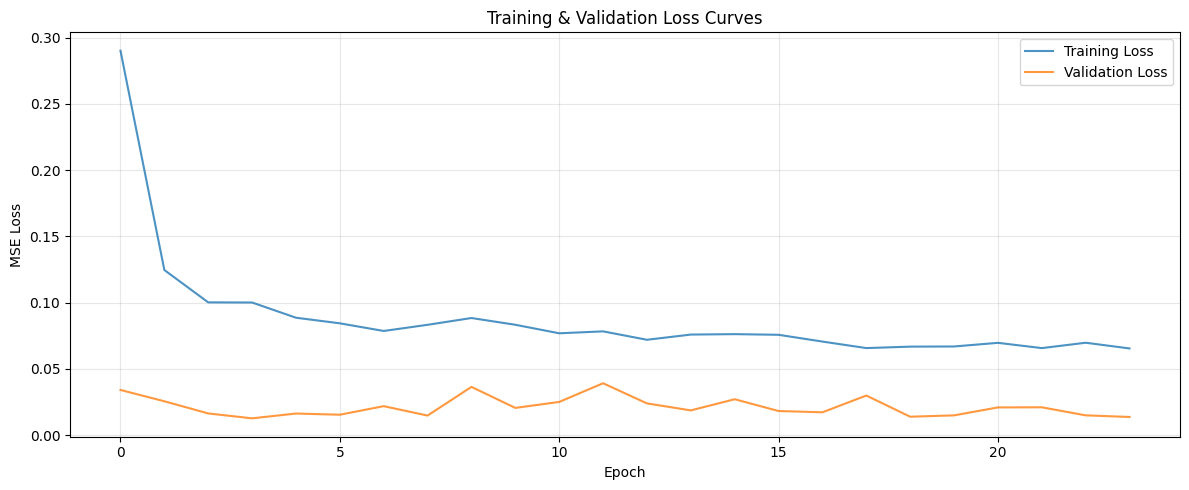

In [13]:
# === Training Curves ===
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_losses, label='Training Loss', alpha=0.8)
ax.plot(val_losses, label='Validation Loss', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training & Validation Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 6: Evaluate on Test Set

In [14]:
# === EVALUATE ON ALL SETS ===
print('='*60)
print('MODEL EVALUATION')
print('='*60)

best_model.eval()
with torch.no_grad():
    # Predictions (scaled)
    train_pred_s = best_model(X_train_t).cpu().numpy()
    val_pred_s = best_model(X_val_t).cpu().numpy()
    test_pred_s = best_model(X_test_t).cpu().numpy()

# Inverse transform to original scale
train_pred = scaler_y.inverse_transform(train_pred_s.reshape(-1, 1)).flatten()
val_pred = scaler_y.inverse_transform(val_pred_s.reshape(-1, 1)).flatten()
test_pred = scaler_y.inverse_transform(test_pred_s.reshape(-1, 1)).flatten()

# Metrics function
def print_metrics(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f'\n  {name}:')
    print(f'    R²   = {r2:.6f} ({r2*100:.2f}%)')
    print(f'    RMSE = {rmse:.4f} kW')
    print(f'    MAE  = {mae:.4f} kW')
    return r2, rmse, mae

r2_train, rmse_train, mae_train = print_metrics('Training Set', y_train, train_pred)
r2_val, rmse_val, mae_val = print_metrics('Validation Set', y_val, val_pred)
r2_test, rmse_test, mae_test = print_metrics('Test Set', y_test, test_pred)

print(f'\n  Summary Table:')
print(f'  {"Set":<15} {"R²":>8} {"RMSE (kW)":>12} {"MAE (kW)":>12}')
print(f'  {"-"*15} {"-"*8} {"-"*12} {"-"*12}')
print(f'  {"Training":<15} {r2_train:>8.4f} {rmse_train:>12.4f} {mae_train:>12.4f}')
print(f'  {"Validation":<15} {r2_val:>8.4f} {rmse_val:>12.4f} {mae_val:>12.4f}')
print(f'  {"Test":<15} {r2_test:>8.4f} {rmse_test:>12.4f} {mae_test:>12.4f}')

MODEL EVALUATION

  Training Set:
    R²   = 0.973526 (97.35%)
    RMSE = 4.0038 kW
    MAE  = 1.6593 kW

  Validation Set:
    R²   = 0.988808 (98.88%)
    RMSE = 2.8909 kW
    MAE  = 1.7493 kW

  Test Set:
    R²   = 0.985327 (98.53%)
    RMSE = 2.8818 kW
    MAE  = 1.8304 kW

  Summary Table:
  Set                   R²    RMSE (kW)     MAE (kW)
  --------------- -------- ------------ ------------
  Training          0.9735       4.0038       1.6593
  Validation        0.9888       2.8909       1.7493
  Test              0.9853       2.8818       1.8304


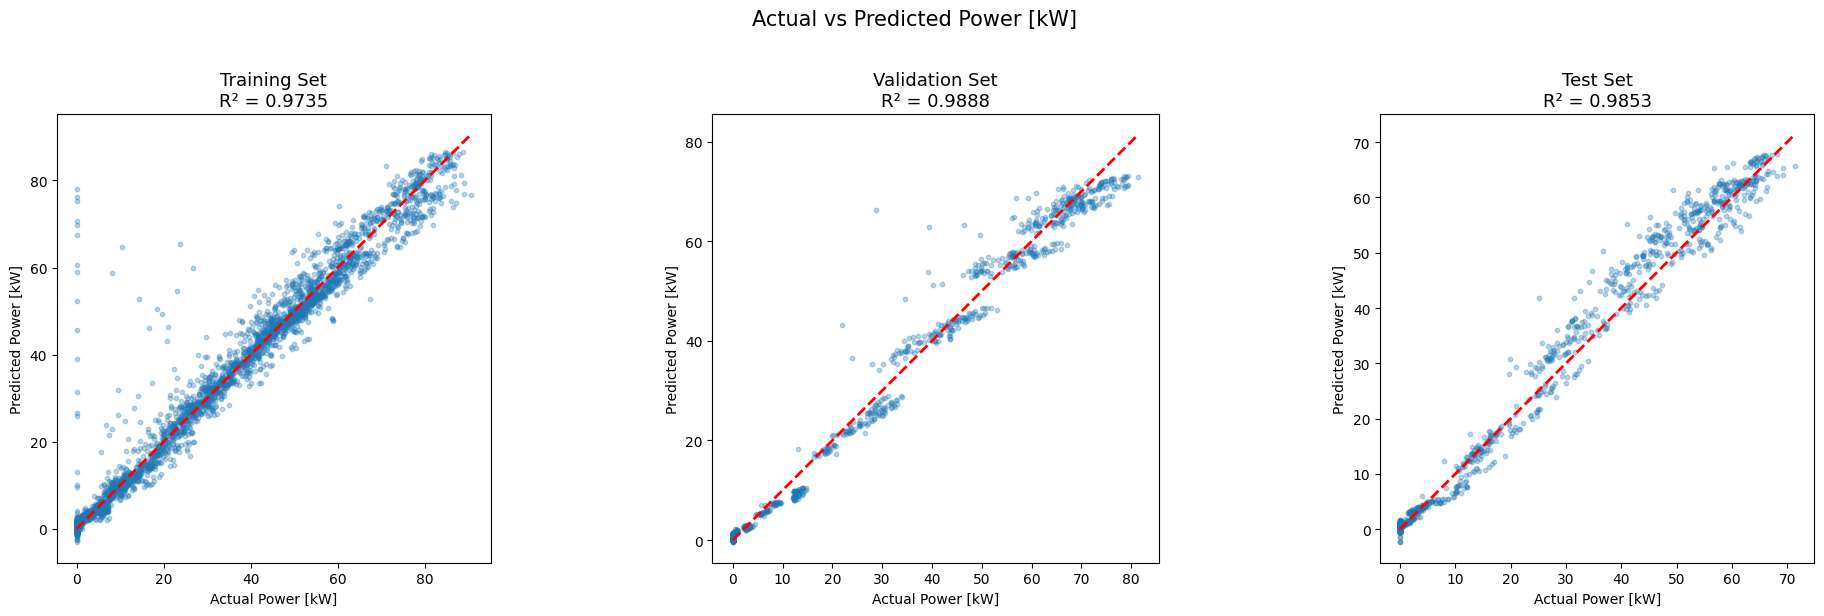

In [15]:
# === VISUALIZATION: Actual vs Predicted ===
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, name, yt, yp, r2 in [
    (axes[0], 'Training', y_train, train_pred, r2_train),
    (axes[1], 'Validation', y_val, val_pred, r2_val),
    (axes[2], 'Test', y_test, test_pred, r2_test)
]:
    ax.scatter(yt, yp, alpha=0.3, s=10)
    ax.plot([0, yt.max()], [0, yt.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Power [kW]')
    ax.set_ylabel('Predicted Power [kW]')
    ax.set_title(f'{name} Set\nR² = {r2:.4f}', fontsize=13)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Actual vs Predicted Power [kW]', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

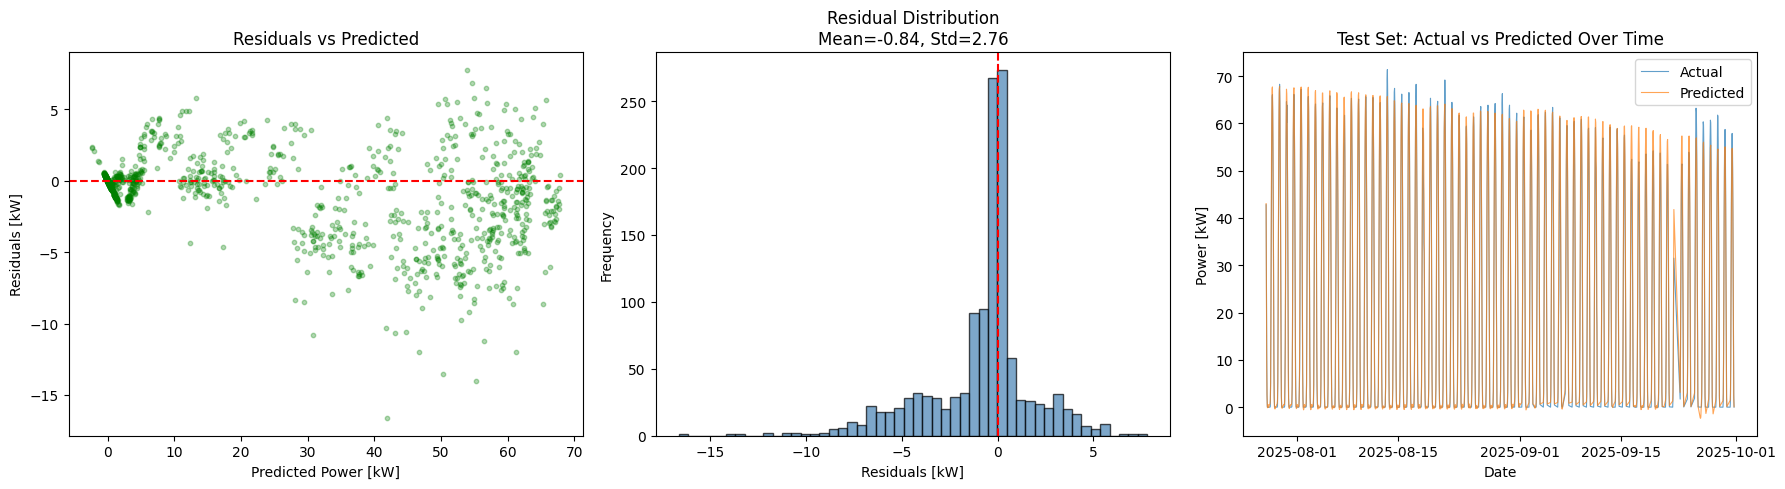

In [16]:
# === RESIDUAL ANALYSIS (Test Set) ===
residuals = y_test - test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs Predicted
axes[0].scatter(test_pred, residuals, alpha=0.3, s=10, color='green')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Power [kW]')
axes[0].set_ylabel('Residuals [kW]')
axes[0].set_title('Residuals vs Predicted')

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Residuals [kW]')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution\nMean={residuals.mean():.2f}, Std={residuals.std():.2f}')

# Time series: Actual vs Predicted
test_dates = df[date_col].values[val_end:]
axes[2].plot(test_dates, y_test, alpha=0.7, label='Actual', linewidth=0.8)
axes[2].plot(test_dates, test_pred, alpha=0.7, label='Predicted', linewidth=0.8)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Power [kW]')
axes[2].set_title('Test Set: Actual vs Predicted Over Time')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Step 7: Model Architecture & Final Summary

In [17]:
# === FINAL SUMMARY ===
print('='*60)
print('NEURAL NETWORK POWER PREDICTION — FULL SUMMARY')
print('='*60)

print(f'\n📦 DATA:')
print(f'  Total samples:    {len(df)}')
print(f'  Features used:    {len(feature_cols)}')
print(f'  Feature list:     {feature_cols}')
print(f'  Training set:     {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)')
print(f'  Validation set:   {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)')
print(f'  Test set:         {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)')

print(f'\n🏗️ BEST NEURAL NETWORK ARCHITECTURE:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')
print(f'  Total parameters: {sum(p.numel() for p in best_model.parameters()):,}')

print(f'\n📊 PERFORMANCE:')
print(f'  {"Set":<15} {"R²":>8} {"RMSE (kW)":>12} {"MAE (kW)":>12}')
print(f'  {"-"*15} {"-"*8} {"-"*12} {"-"*12}')
print(f'  {"Training":<15} {r2_train:>8.4f} {rmse_train:>12.4f} {mae_train:>12.4f}')
print(f'  {"Validation":<15} {r2_val:>8.4f} {rmse_val:>12.4f} {mae_val:>12.4f}')
print(f'  {"Test":<15} {r2_test:>8.4f} {rmse_test:>12.4f} {mae_test:>12.4f}')

print(f'\n🔍 COMPARISON WITH LINEAR REGRESSION:')
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(X_train_scaled, y_train)
lr_test_pred = lr.predict(X_test_scaled)
r2_lr = r2_score(y_test, lr_test_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_test_pred))
print(f'  Linear Regression:    R² = {r2_lr:.4f}, RMSE = {rmse_lr:.4f} kW')
print(f'  Neural Network:       R² = {r2_test:.4f}, RMSE = {rmse_test:.4f} kW')
improvement = (r2_test - r2_lr) / abs(r2_lr) * 100 if r2_lr != 0 else float('inf')
print(f'  NN improvement:       {improvement:+.1f}% R² improvement over Linear Regression')

print(f'\n🎯 VERDICT:')
if r2_test > 0.9:
    print(f'  ✅ EXCELLENT — The NN predicts Power very accurately (R² = {r2_test:.4f})')
elif r2_test > 0.7:
    print(f'  ✅ GOOD — The NN predicts Power well (R² = {r2_test:.4f})')
elif r2_test > 0.5:
    print(f'  ⚠️ MODERATE — The NN captures the main pattern (R² = {r2_test:.4f})')
else:
    print(f'  ❌ POOR — The NN needs more features or tuning (R² = {r2_test:.4f})')

print(f'\n  The Sunlight feature helps the model learn nighttime = zero power.')
print(f'  POA Irradiance is the dominant predictor of Power output.')

NEURAL NETWORK POWER PREDICTION — FULL SUMMARY

📦 DATA:
  Total samples:    8621
  Features used:    14
  Feature list:     ['POA irradiance (sensor) [W/m²]', 'Sunlight', 'Hour', 'Month', 'DayOfYear', 'DayOfWeek', 'WeekOfYear', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'DayOfYear_sin', 'DayOfYear_cos', 'Timestamp_h']
  Training set:     6034 (70.0%)
  Validation set:   1293 (15.0%)
  Test set:         1294 (15.0%)

🏗️ BEST NEURAL NETWORK ARCHITECTURE:
  n_layers: 2
  n_units: 128
  dropout: 0.30000000000000004
  lr: 0.0015304852121831463
  batch_size: 64
  Total parameters: 19,073

📊 PERFORMANCE:
  Set                   R²    RMSE (kW)     MAE (kW)
  --------------- -------- ------------ ------------
  Training          0.9735       4.0038       1.6593
  Validation        0.9888       2.8909       1.7493
  Test              0.9853       2.8818       1.8304

🔍 COMPARISON WITH LINEAR REGRESSION:
  Linear Regression:    R² = 0.9298, RMSE = 6.3033 kW
  Neural Network:       R² = 0.